In [1]:
import sys, os, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
from torch.utils.data import DataLoader, WeightedRandomSampler
from tqdm import tqdm
from collections import defaultdict
from matplotlib.patches import Patch
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

sys.path.insert(0, os.path.abspath(".."))
from wood_utils import *
plt.rcParams.update(PLOT_RCPARAMS)

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

OUT_DIR   = "../logs/20_trees_SegFormer"
CACHE_DIR = "./cache"
os.makedirs(os.path.join(OUT_DIR, 'checkpoints'), exist_ok=True)
os.makedirs(CACHE_DIR, exist_ok=True)

BATCH_SIZE          = 8
EPOCHS              = 200
LR                  = 5e-4
EARLY_STOP          = 15
REPEAT              = 5
DEFECT_SAMPLE_RATIO = 0.75


Device: cuda


In [2]:
all_pairs = build_pairs(IMAGES_ROOT, GT_ROOT)
log_pairs = group_by_log(all_pairs, IMAGES_ROOT)
all_logs  = sorted(log_pairs.keys())
print(f"Total pairs : {len(all_pairs)}")
print(f"All logs    : {all_logs}")


Total pairs : 1347
All logs    : ['Dub 1', 'Dub 10', 'Dub 2', 'Dub 3', 'Dub 4', 'Dub 5', 'Dub 6', 'Dub 7', 'Dub 8', 'Dub 9', 'kmen1', 'kmen10', 'kmen2', 'kmen3', 'kmen4', 'kmen5', 'kmen6', 'kmen7', 'kmen8', 'kmen9']


In [3]:
# EDA: Dub 3 + kmen7 (heaviest) in train
#       Val:  one mixed log per batch  (Dub 4, kmen6)
#       Test: knot-dominant + crack-dominant (Dub 9, kmen9)
#       Near-zero logs (Dub 10, kmen1, kmen10) in train as hard negatives
def get_log_id(img_path):
    parts     = img_path.replace("\\", "/").split("/")
    log_names = set(os.listdir(IMAGES_ROOT))
    return next((p for p in parts if p in log_names), None)
 
log_pairs = defaultdict(list)
for pair in all_pairs:
    log_id = get_log_id(pair[0])
    if log_id:
        log_pairs[log_id].append(pair)
 
all_logs   = sorted(log_pairs.keys())
VAL_LOGS   = ["Dub 4", "kmen6"]
TEST_LOGS  = ["Dub 9", "kmen9"]
TRAIN_LOGS = [l for l in all_logs if l not in VAL_LOGS + TEST_LOGS]
 
train_pairs = [p for lg in TRAIN_LOGS for p in log_pairs[lg]]
val_pairs   = [p for lg in VAL_LOGS   for p in log_pairs[lg]]
test_pairs  = [p for lg in TEST_LOGS  for p in log_pairs[lg]]
 
print(f"All logs   : {all_logs}")
print(f"Train logs : {TRAIN_LOGS}")
print(f"Val logs   : {VAL_LOGS}")
print(f"Test logs  : {TEST_LOGS}")
print(f"Train: {len(train_pairs)} | Val: {len(val_pairs)} | Test: {len(test_pairs)}")

All logs   : ['Dub 1', 'Dub 10', 'Dub 2', 'Dub 3', 'Dub 4', 'Dub 5', 'Dub 6', 'Dub 7', 'Dub 8', 'Dub 9', 'kmen1', 'kmen10', 'kmen2', 'kmen3', 'kmen4', 'kmen5', 'kmen6', 'kmen7', 'kmen8', 'kmen9']
Train logs : ['Dub 1', 'Dub 10', 'Dub 2', 'Dub 3', 'Dub 5', 'Dub 6', 'Dub 7', 'Dub 8', 'kmen1', 'kmen10', 'kmen2', 'kmen3', 'kmen4', 'kmen5', 'kmen7', 'kmen8']
Val logs   : ['Dub 4', 'kmen6']
Test logs  : ['Dub 9', 'kmen9']
Train: 1090 | Val: 129 | Test: 128


In [4]:
cached_train = build_cache(train_pairs, os.path.join(CACHE_DIR, "train_log"), force=False)
cached_val   = build_cache(val_pairs,   os.path.join(CACHE_DIR, "val_log"),   force=False)
cached_test  = build_cache(test_pairs,  os.path.join(CACHE_DIR, "test"),       force=False)


Caching → train_log: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1090/1090 [00:28<00:00, 38.63it/s]


  Cache OK — img: (1, 256, 256) float32 | mask: (256, 256) unique: [0, 1, 2, 4]


Caching → val_log: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 129/129 [00:05<00:00, 22.26it/s]


  Cache OK — img: (1, 256, 256) float32 | mask: (256, 256) unique: [0, 1, 2, 4]


Caching → test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 128/128 [00:00<00:00, 7111.91it/s]


  Cache OK — img: (1, 256, 256) float32 | mask: (256, 256) unique: [0, 1, 2, 4]


In [5]:
train_dataset = WoodTrainDataset(cached_train, repeat=REPEAT)
val_dataset   = WoodValDataset(cached_val)
test_dataset  = WoodValDataset(cached_test)
sampler = make_defect_aware_sampler(cached_train, repeat=REPEAT,
                                    defect_sample_ratio=DEFECT_SAMPLE_RATIO)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)


  Defect-aware sampler: 4175 defect / 1275 clean  (target ratio 75%)


In [6]:
import segmentation_models_pytorch as smp
import torchvision.models as tvm
 
# -- MODEL SELECTOR -------------------------------------------
# Set to "unetpp" or "segformer"
MODEL_TYPE = "segformer"
 
def build_unetpp():
    """UNet++ with ResNet34 encoder - pretrained weights via torchvision."""
    model = smp.UnetPlusPlus(
        encoder_name    = "resnet34",
        encoder_weights = None,
        in_channels     = 1,
        classes         = NUM_CLASSES,
        activation      = None,
    )
    enc_w = tvm.resnet34(weights=tvm.ResNet34_Weights.IMAGENET1K_V1).state_dict()
    enc_w["conv1.weight"] = enc_w["conv1.weight"].mean(dim=1, keepdim=True)
    model_dict = model.encoder.state_dict()
    matched    = {k: v for k, v in enc_w.items()
                  if k in model_dict and v.shape == model_dict[k].shape}
    model_dict.update(matched)
    model.encoder.load_state_dict(model_dict, strict=False)
    print(f"  UNet++ encoder weights loaded: {len(matched)}/{len(model_dict)}")
    return model
 
 
def remap_segformer_keys(ckpt, model_dict):
    remapped = {}
    for ck, cv in ckpt.items():
        parts = ck.split(".")
        if parts[0] != "layers" or len(parts) < 3:
            continue
        stage     = int(parts[1])
        component = int(parts[2])
        rest      = ".".join(parts[3:])

        if component == 0:
            rest  = rest.replace("projection.", "proj.")
            new_k = f"patch_embed{stage+1}.{rest}"
            if new_k in model_dict:
                mv = model_dict[new_k]
                if cv.shape == mv.shape:
                    remapped[new_k] = cv
                elif cv.ndim == 4 and cv.shape[1] == 3 and mv.shape[1] == 1:
                    remapped[new_k] = cv.mean(dim=1, keepdim=True)

        elif component == 1:
            block_idx = parts[3]
            inner     = ".".join(parts[4:])
            prefix    = f"block{stage+1}.{block_idx}"

            if inner in ("norm1.weight", "norm1.bias",
                         "norm2.weight", "norm2.bias",
                         "attn.sr.weight", "attn.sr.bias",
                         "attn.norm.weight", "attn.norm.bias"):
                new_k = f"{prefix}.{inner}"
                if new_k in model_dict:
                    remapped[new_k] = cv

            elif inner == "attn.attn.in_proj_weight":
                C = cv.shape[1]
                if f"{prefix}.attn.q.weight" in model_dict:
                    remapped[f"{prefix}.attn.q.weight"]  = cv[:C]
                    remapped[f"{prefix}.attn.kv.weight"] = cv[C:]
            elif inner == "attn.attn.in_proj_bias":
                C = cv.shape[0] // 3
                if f"{prefix}.attn.q.bias" in model_dict:
                    remapped[f"{prefix}.attn.q.bias"]  = cv[:C]
                    remapped[f"{prefix}.attn.kv.bias"] = cv[C:]
            elif inner == "attn.attn.out_proj.weight":
                new_k = f"{prefix}.attn.proj.weight"
                if new_k in model_dict: remapped[new_k] = cv
            elif inner == "attn.attn.out_proj.bias":
                new_k = f"{prefix}.attn.proj.bias"
                if new_k in model_dict: remapped[new_k] = cv

            elif inner == "ffn.layers.0.weight":
                new_k = f"{prefix}.mlp.fc1.weight"
                if new_k in model_dict: remapped[new_k] = cv.squeeze(-1).squeeze(-1)
            elif inner == "ffn.layers.0.bias":
                new_k = f"{prefix}.mlp.fc1.bias"
                if new_k in model_dict: remapped[new_k] = cv
            elif inner == "ffn.layers.1.weight":
                new_k = f"{prefix}.mlp.dwconv.dwconv.weight"
                if new_k in model_dict: remapped[new_k] = cv
            elif inner == "ffn.layers.1.bias":
                new_k = f"{prefix}.mlp.dwconv.dwconv.bias"
                if new_k in model_dict: remapped[new_k] = cv
            elif inner == "ffn.layers.4.weight":
                new_k = f"{prefix}.mlp.fc2.weight"
                if new_k in model_dict: remapped[new_k] = cv.squeeze(-1).squeeze(-1)
            elif inner == "ffn.layers.4.bias":
                new_k = f"{prefix}.mlp.fc2.bias"
                if new_k in model_dict: remapped[new_k] = cv

        elif component == 2:
            new_k = f"norm{stage+1}.{rest}"
            if new_k in model_dict:
                remapped[new_k] = cv

    return remapped


def build_segformer():
    import urllib.request
    MIT_B2_URL  = ("https://download.openmmlab.com/mmsegmentation/v0.5/"
                   "pretrain/segformer/mit_b2_20220624-66e8bf70.pth")
    MIT_B2_PATH = "./mit_b2_imagenet.pth"

    if not os.path.exists(MIT_B2_PATH):
        print("  Downloading mit_b2 weights from OpenMMLab CDN...")
        urllib.request.urlretrieve(MIT_B2_URL, MIT_B2_PATH)
        print(f"  Saved -> {MIT_B2_PATH}")

    model = smp.Segformer(
        encoder_name    = "mit_b2",
        encoder_weights = None,
        in_channels     = 1,
        classes         = NUM_CLASSES,
        activation      = None,
    )

    enc_w      = torch.load(MIT_B2_PATH, map_location="cpu")
    model_dict = model.encoder.state_dict()
    matched    = remap_segformer_keys(enc_w, model_dict)
    model_dict.update(matched)
    nn.Module.load_state_dict(model.encoder, model_dict, strict=False)
    print(f"  Segformer encoder weights loaded: {len(matched)}/{len(model_dict)}")
    return model
 
 
def build_model():
    if MODEL_TYPE == "segformer":
        return build_segformer()
    return build_unetpp()

In [7]:
# Loss
USE_MRF   = False
criterion = CombinedLoss(weight=CLASS_WEIGHTS.to(device))


In [8]:
def compute_metrics(preds, targets):
    """Training-specific metrics: per-class + defect aggregates."""
    preds = preds.view(-1); targets = targets.view(-1)
    results = {}
    ious, dices, recalls = [], [], []
    for c in range(NUM_CLASSES):
        pred_c = preds == c; target_c = targets == c
        tp = (pred_c &  target_c).sum().item()
        fp = (pred_c & ~target_c).sum().item()
        fn = (~pred_c & target_c).sum().item()
        iou    = tp / (tp+fp+fn)      if (tp+fp+fn)    > 0 else float("nan")
        dice   = 2*tp/(2*tp+fp+fn)    if (2*tp+fp+fn)  > 0 else float("nan")
        recall = tp / (tp+fn)          if (tp+fn)       > 0 else float("nan")
        results[CLASS_NAMES[c]] = {"iou": iou, "dice": dice, "recall": recall}
        ious.append(iou); dices.append(dice); recalls.append(recall)
    results["mean_iou"]        = float(np.nanmean(ious))
    results["defect_iou"]      = float(np.nanmean([ious[c]    for c in DEFECT_CLASSES]))
    results["defect_dice"]     = float(np.nanmean([dices[c]   for c in DEFECT_CLASSES]))
    results["defect_recall"]   = float(np.nanmean([recalls[c] for c in DEFECT_CLASSES]))
    return results

def print_metrics(metrics, prefix=""):
    print(f"\n{'-'*50}\n {prefix} Metrics\n{'-'*50}")
    print(f"  {'Class':<12} {'IoU':>8} {'Dice':>8} {'Recall':>8}")
    print(f"  {'-'*38}")
    for name in CLASS_NAMES:
        m = metrics[name]
        iou    = f"{m['iou']:.4f}"    if not np.isnan(m['iou'])    else "   n/a"
        dice   = f"{m['dice']:.4f}"   if not np.isnan(m['dice'])   else "   n/a"
        recall = f"{m['recall']:.4f}" if not np.isnan(m['recall']) else "   n/a"
        print(f"  {name:<12} {iou:>8} {dice:>8} {recall:>8}")
    print(f"{'-'*50}")
    print(f"  Mean IoU      : {metrics['mean_iou']:.4f}")
    print(f"  Defect IoU    : {metrics['defect_iou']:.4f}")
    print(f"  Defect Dice   : {metrics['defect_dice']:.4f}")
    print(f"  Defect Recall : {metrics['defect_recall']:.4f}")
    print(f"{'-'*50}\n")


In [9]:
def evaluate(model, loader, criterion):
    model.eval()
    total_loss  = 0.0
    all_preds, all_targets = [], []
 
    with torch.no_grad():
        for imgs, masks in tqdm(loader, desc="Evaluating", leave=False):
            imgs, masks  = imgs.to(device), masks.to(device)
            outputs      = model(imgs)
            total_loss  += criterion(outputs, masks).item()
            preds = torch.argmax(outputs, dim=1).cpu()
            all_preds.append(preds.reshape(-1))
            all_targets.append(masks.cpu().reshape(-1))
 
    all_preds   = torch.cat(all_preds)
    all_targets = torch.cat(all_targets)
    return total_loss / len(loader), compute_metrics(all_preds, all_targets)
 
 
def train():
    model     = build_model().to(device)
    criterion = CombinedLoss().to(device)
 
    # -- model-specific optimizer -----------------------------
    if MODEL_TYPE == "segformer":
        # AdamW + differential LR - standard for transformers
        optimizer = optim.AdamW([
            {"params": model.encoder.parameters(), "lr": LR * 0.1},
            {"params": model.decoder.parameters(), "lr": LR},
        ], weight_decay=0.01)
    else:
        # UNet++ - differential LR for pretrained encoder
        optimizer = optim.Adam([
            {"params": model.encoder.parameters(), "lr": LR * 0.1},
            {"params": model.decoder.parameters(), "lr": LR},
            {"params": model.segmentation_head.parameters(), "lr": LR},
        ])
 
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=LR * 0.01)
    stopper   = EarlyStopping(patience=EARLY_STOP)
 
    best_defect_iou = 0.0
    best_epoch      = 0
    history = {
        "train_loss":       [],
        "val_loss":         [],
        "val_defect_iou":   [],
        "val_defect_dice":  [],
        "val_defect_recall":[],
    }
 
    for epoch in range(1, EPOCHS + 1):
        model.train()
        running_loss = 0.0
        train_preds, train_targets = [], []
 
        for imgs, masks in tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS}"):
            imgs, masks = imgs.to(device), masks.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss    = criterion(outputs, masks)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            train_preds.append(torch.argmax(outputs, dim=1).cpu().reshape(-1))
            train_targets.append(masks.cpu().reshape(-1))
 
        train_loss    = running_loss / len(train_loader)
        train_metrics = compute_metrics(torch.cat(train_preds), torch.cat(train_targets))
        val_loss, val_metrics = evaluate(model, val_loader, criterion)
 
        scheduler.step()
        current_lr = optimizer.param_groups[0]["lr"]
 
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_defect_iou"].append(val_metrics["defect_iou"])
        history["val_defect_dice"].append(val_metrics["defect_dice"])
        history["val_defect_recall"].append(val_metrics["defect_recall"])
 
        print(
            f"Epoch {epoch:>3}/{EPOCHS} | "
            f"Loss {train_loss:.4f}/{val_loss:.4f} | "
            f"Defect IoU {train_metrics['defect_iou']:.4f}/{val_metrics['defect_iou']:.4f} | "
            f"Defect Recall {val_metrics['defect_recall']:.4f} | "
            f"LR {current_lr:.2e}"
        )
 
        # EDA: save best on defect IoU, not mean IoU
        if val_metrics["defect_iou"] > best_defect_iou:
            best_defect_iou = val_metrics["defect_iou"]
            best_epoch      = epoch
            torch.save(model.state_dict(),
                       os.path.join(OUT_DIR, "checkpoints", "best.pt"))
            print(f"  ✓ Best saved (Defect IoU={best_defect_iou:.4f})")
 
        stopper(val_loss)
        if stopper.early_stop:
            print(f"Early stopping at epoch {epoch}.")
            break
 
    print(f"\nDone. Best epoch: {best_epoch} | Best Defect IoU: {best_defect_iou:.4f}")
    return model, history
 
 
model, history = train()

  Segformer encoder weights loaded: 332/332


Epoch 1/200: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 682/682 [01:50<00:00,  6.19it/s]
                                                                                                                                                                                                                                                                                                                   

Epoch   1/200 | Loss 0.2232/0.2304 | Defect IoU 0.1069/0.3461 | Defect Recall 0.5715 | LR 5.00e-05
  ✓ Best saved (Defect IoU=0.3461)


Epoch 2/200: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 682/682 [01:42<00:00,  6.62it/s]
                                                                                                                                                                                                                                                                                                                   

Epoch   2/200 | Loss 0.1595/0.2091 | Defect IoU 0.3904/0.3690 | Defect Recall 0.5959 | LR 5.00e-05
  ✓ Best saved (Defect IoU=0.3690)


...

Epoch  32/200 | Loss 0.1124/4.1125 | Defect IoU 0.4849/0.0414 | Defect Recall 0.5519 | LR 4.72e-05


Epoch 33/200: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 682/682 [01:31<00:00,  7.45it/s]
                                                                                                                                                                                                                                                                                                                   

Epoch  33/200 | Loss 0.1141/0.7960 | Defect IoU 0.4777/0.0000 | Defect Recall 0.0000 | LR 4.70e-05


Epoch 34/200: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 682/682 [01:31<00:00,  7.48it/s]
                                                                                                                                                                                                                                                                                                                   

Epoch  34/200 | Loss 0.1097/0.4765 | Defect IoU 0.4833/0.0000 | Defect Recall 0.0000 | LR 4.69e-05
Early stopping at epoch 34.

Done. Best epoch: 19 | Best Defect IoU: 0.4083


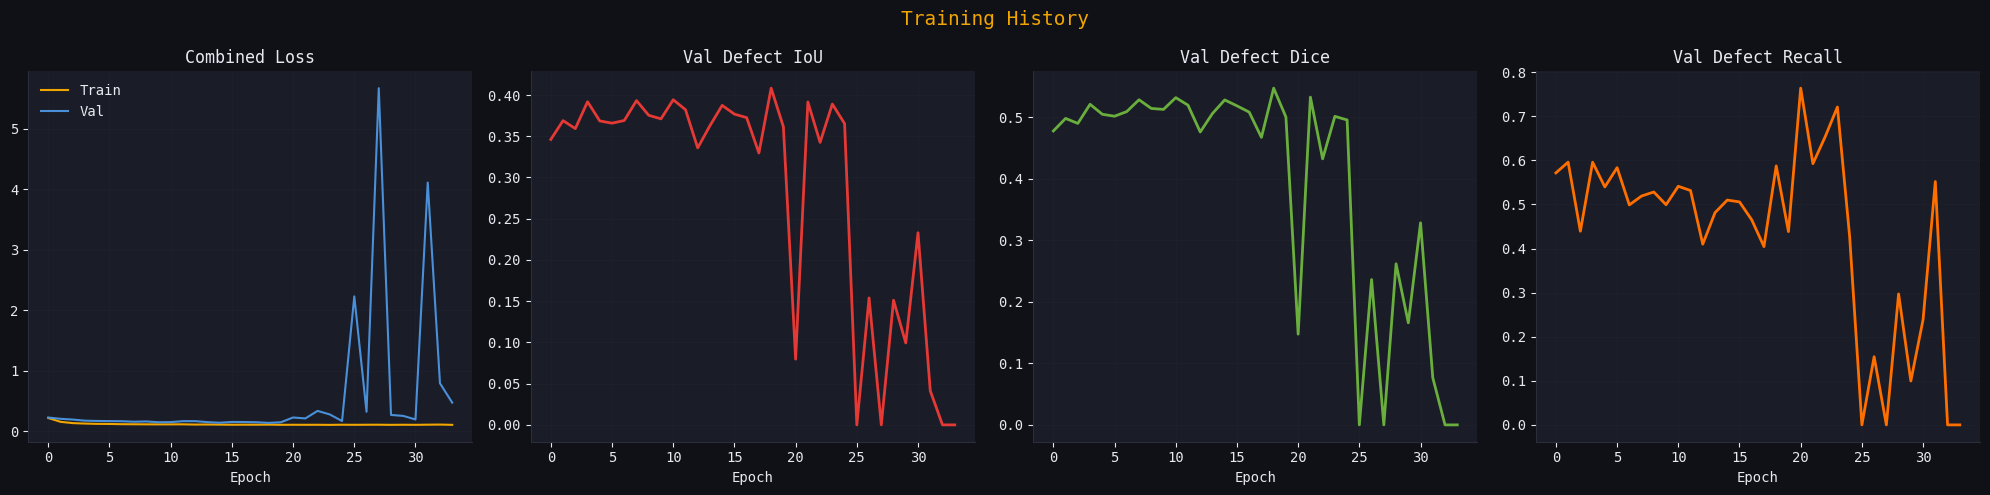

In [10]:
DARK_BG  = "#0F1117"
PANEL_BG = "#1A1D27"
TEXT_COL = "#E8E8F0"
GRID_COL = "#2A2D3A"
ACCENT   = "#F0A500"
 
plt.rcParams.update({
    "figure.facecolor": DARK_BG, "axes.facecolor": PANEL_BG,
    "axes.edgecolor":   GRID_COL, "axes.labelcolor": TEXT_COL,
    "axes.titlecolor":  TEXT_COL, "xtick.color":     TEXT_COL,
    "ytick.color":      TEXT_COL, "text.color":      TEXT_COL,
    "grid.color":       GRID_COL, "font.family":     "monospace",
    "axes.spines.top":  False,    "axes.spines.right": False,
})
 
fig, axes = plt.subplots(1, 4, figsize=(20, 5), facecolor=DARK_BG)
 
axes[0].plot(history["train_loss"], color=ACCENT,    label="Train")
axes[0].plot(history["val_loss"],   color="#4A90D9", label="Val")
axes[0].set_title("Combined Loss",               fontsize=12)
axes[0].set_xlabel("Epoch")
axes[0].legend(framealpha=0, labelcolor=TEXT_COL)
axes[0].grid(alpha=0.3)
 
axes[1].plot(history["val_defect_iou"],    color="#E53935", linewidth=2)
axes[1].set_title("Val Defect IoU",        fontsize=12)
axes[1].set_xlabel("Epoch")
axes[1].grid(alpha=0.3)
 
axes[2].plot(history["val_defect_dice"],   color="#6AAF3D", linewidth=2)
axes[2].set_title("Val Defect Dice",       fontsize=12)
axes[2].set_xlabel("Epoch")
axes[2].grid(alpha=0.3)
 
axes[3].plot(history["val_defect_recall"], color="#FF6F00", linewidth=2)
axes[3].set_title("Val Defect Recall",     fontsize=12)
axes[3].set_xlabel("Epoch")
axes[3].grid(alpha=0.3)
 
plt.suptitle("Training History", fontsize=14, color=ACCENT)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "training_curves.png"), dpi=150, bbox_inches="tight")
plt.show()
 

In [11]:
best_model = build_model().to(device)
best_model.load_state_dict(
    torch.load(os.path.join(OUT_DIR, "checkpoints", "best.pt"), map_location=device)
)
criterion = CombinedLoss().to(device)
 
_, test_metrics = evaluate(best_model, test_loader, criterion)
print_metrics(test_metrics, prefix="TEST SET")

  Segformer encoder weights loaded: 332/332



--------------------------------------------------
 TEST SET Metrics
--------------------------------------------------
  Class             IoU     Dice   Recall
  --------------------------------------
  Background     0.9951   0.9976   0.9982
  Bark           0.5843   0.7376   0.8984
  Wood           0.9568   0.9779   0.9583
  Knot           0.6000   0.7500   0.9886
  Crack          0.2932   0.4535   0.6185
--------------------------------------------------
  Mean IoU      : 0.6859
  Defect IoU    : 0.4466
  Defect Dice   : 0.6017
  Defect Recall : 0.8036
--------------------------------------------------



NameError: name 'CLASS_COLORS' is not defined

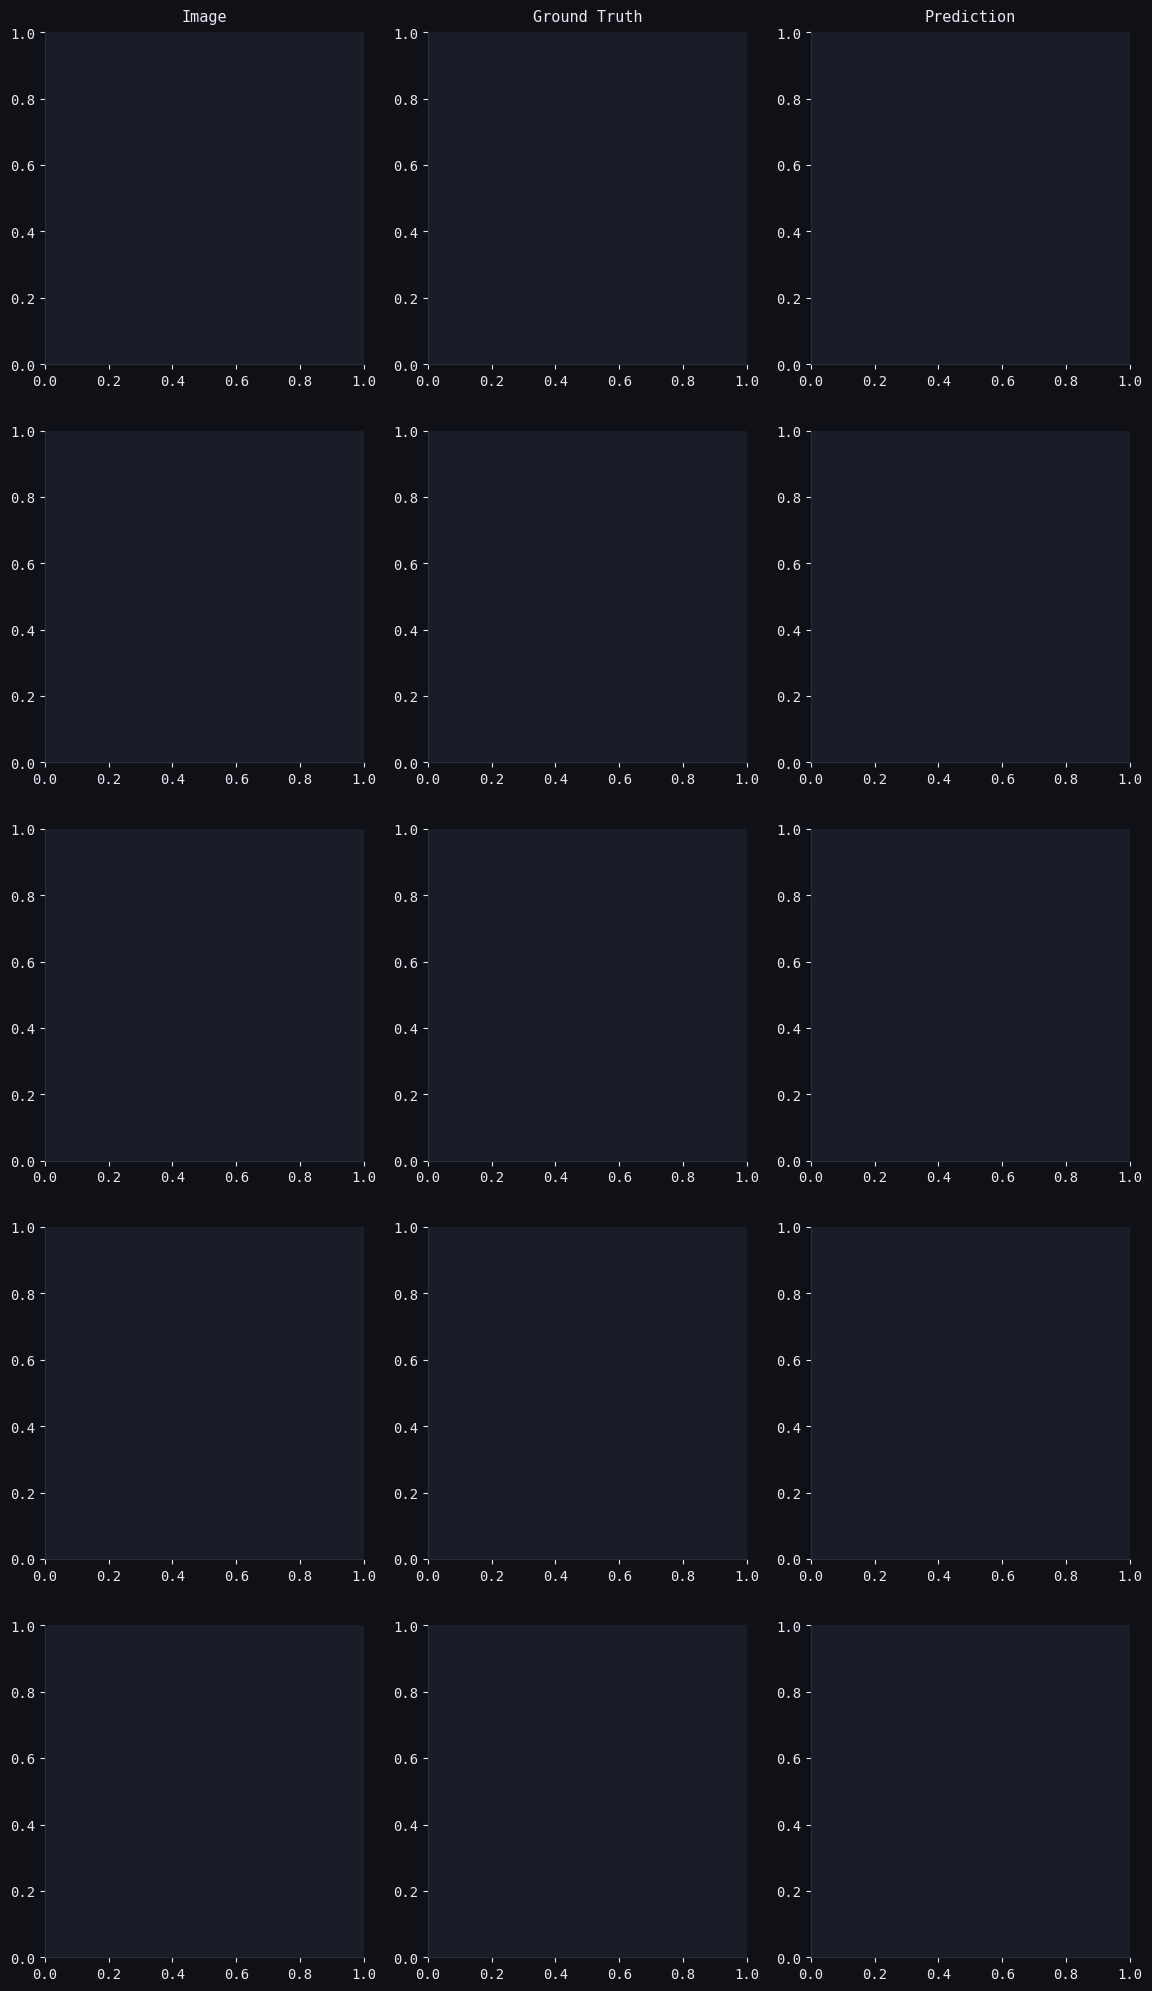

In [12]:
# Two sections:
#   A) First N_VIS samples from test set (general)
#   B) kmen9-specific samples (crack-heavy log)
def colorise_mask(mask_np):
    rgb = np.zeros((*mask_np.shape, 3), dtype=np.float32)
    for c, hx in CLASS_COLORS.items():
        r, g, b = [int(hx[i:i+2], 16) / 255 for i in (1, 3, 5)]
        rgb[mask_np == c] = [r, g, b]
    return rgb


def predict_single(model, img_npy, use_mrf=USE_MRF):
    """Run inference on a single cached image, return prediction mask."""
    img = torch.tensor(np.load(img_npy)).unsqueeze(0).to(device)
    with torch.no_grad():
        probs = F.softmax(model(img), dim=1).squeeze(0)   # (C, H, W)
    if use_mrf:
        return mrf_gibbs_sampling(probs).cpu().numpy()
    return torch.argmax(probs, dim=0).cpu().numpy()


def visualise_samples(indices, title, save_name, n_vis=5):
    """
    Visualise a specific set of test indices.
    indices: list of integer indices into cached_test / test_pairs
    """
    indices = indices[:n_vis]
    n       = len(indices)
    if n == 0:
        print(f"No samples found for: {title}")
        return

    fig, axes = plt.subplots(n, 3, figsize=(14, 5 * n), facecolor=DARK_BG)
    if n == 1:
        axes = [axes]   # ensure 2D indexing works for single row

    for col, t in enumerate(["Image", "Ground Truth", "Prediction"]):
        axes[0][col].set_title(t, fontsize=11, pad=8)

    legend_patches = [Patch(color=CLASS_COLORS[c], label=CLASS_NAMES[c])
                      for c in range(NUM_CLASSES)]

    for row, idx in enumerate(indices):
        img_npy, mask_npy = cached_test[idx]
        orig_path         = test_pairs[idx][0]

        img_np  = np.load(img_npy)[0]         # (H, W) - first channel only for display
        mask_np = np.load(mask_npy)
        pred_np = predict_single(best_model, img_npy)

        # count crack pixels for context
        gt_crack   = int((mask_np == 4).sum())
        pred_crack = int((pred_np == 4).sum())
        tp_crack   = int(((mask_np == 4) & (pred_np == 4)).sum())
        recall_str = f"{tp_crack/gt_crack:.2f}" if gt_crack > 0 else "n/a"

        axes[row][0].imshow(img_np, cmap="gray")
        axes[row][0].set_ylabel(os.path.basename(orig_path), fontsize=6,
                                color=TEXT_COL, rotation=0, labelpad=80, va="center")
        axes[row][1].imshow(colorise_mask(mask_np))
        axes[row][1].set_title(f"GT crack px: {gt_crack}", fontsize=8, pad=4)
        axes[row][2].imshow(colorise_mask(pred_np))
        axes[row][2].set_title(f"Pred crack px: {pred_crack}  Recall: {recall_str}",
                               fontsize=8, pad=4)
        axes[row][2].legend(handles=legend_patches, fontsize=7, loc="lower right",
                            framealpha=0.5, facecolor=DARK_BG, labelcolor="white")
        for ax in axes[row]:
            ax.axis("off")

    mrf_tag = " + MRF" if USE_MRF else ""
    plt.suptitle(f"{title}{mrf_tag}", fontsize=13, color=ACCENT, y=1.005)
    plt.tight_layout()
    save_path = os.path.join(OUT_DIR, save_name)
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved -> {save_path}")


# A) General test set samples
general_indices = list(range(min(5, len(cached_test))))
visualise_samples(general_indices, "Test Set Predictions", "test_predictions.png")

# B) kmen9-specific samples (crack-dominant log)
kmen9_indices = [
    i for i, (_, mp) in enumerate(cached_test)
    if "kmen9" in test_pairs[i][0].replace("\\", "/")
]
print(f"\nkmen9 samples in test set: {len(kmen9_indices)}")

# sort by crack pixel count descending - show hardest cases first
kmen9_indices.sort(
    key=lambda i: int((np.load(cached_test[i][1]) == 4).sum()),
    reverse=True
)
visualise_samples(kmen9_indices, "kmen9 - Crack-dominant Log", "test_kmen9_predictions.png", n_vis=8)

# C) Dub9-specific samples (knot-dominant log)
dub9_indices = [
    i for i, (_, mp) in enumerate(cached_test)
    if "Dub 9" in test_pairs[i][0].replace("\\", "/")
    or "Dub9"  in test_pairs[i][0].replace("\\", "/")
]
print(f"Dub 9 samples in test set: {len(dub9_indices)}")

dub9_indices.sort(
    key=lambda i: int((np.load(cached_test[i][1]) == 3).sum()),
    reverse=True
)
visualise_samples(dub9_indices, "Dub 9 - Knot-dominant Log", "test_dub9_predictions.png", n_vis=8)

In [ ]:
# Per-log crack recall on test set
best_model.eval()
log_results = defaultdict(lambda: {"tp": 0, "fn": 0})

for i, (img_npy, mask_npy) in enumerate(tqdm(cached_test, desc="Per-log eval")):
    orig_img_path = test_pairs[i][0]
    log_id        = get_log_id(orig_img_path)

    img  = torch.tensor(np.load(img_npy)).unsqueeze(0).to(device)
    mask = torch.tensor(np.load(mask_npy))   # (H, W)

    with torch.no_grad():
        probs = F.softmax(best_model(img), dim=1).squeeze(0)   # (C, H, W)

    if USE_MRF:
        pred = mrf_gibbs_sampling(probs).cpu()
    else:
        pred = torch.argmax(probs, dim=0).cpu()

    crack_cls = 4
    tp = int(((pred == crack_cls) & (mask == crack_cls)).sum())
    fn = int(((pred != crack_cls) & (mask == crack_cls)).sum())

    log_results[log_id]["tp"] += tp
    log_results[log_id]["fn"] += fn

print("\nPer-log Crack Recall:")
for log_id, v in sorted(log_results.items()):
    total  = v["tp"] + v["fn"]
    recall = v["tp"] / total if total > 0 else float("nan")
    print(f"  {log_id:<12} recall={recall:.4f}  (tp={v['tp']:,}  fn={v['fn']:,}  total_crack_px={total:,})")